In [39]:
import pandas as pd
import numpy as np
import os
import pyodbc 
import sqlalchemy as sa
from IPython.display import display
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_PATH = r'C:\projects\IdahoSTDM\ITD_STDM\IdahoSTDM\ITDSTDM\inputs'
CONTROLS_PATH = r'C:\projects\IdahoSTDM\ITD_STDM\IdahoSTDM\ITDSTDM\inputs\PopSyn'
OUTPUT_PATH = r'C:\projects\IdahoSTDM\ITD_STDM\IdahoSTDM\ITDSTDM\outputs_2010'

co_fips = {16001: 'Ada', 16003: 'Adams', 16005: 'Bannock', 16007: 'Bear Lake', 16009: 'Benewah', 16011: 'Bingham', 16013: 'Blaine', 
    16015: 'Boise', 16017: 'Bonner', 16019: 'Bonneville', 16021: 'Boundary', 16023: 'Butte', 16025: 'Camas', 16027: 'Canyon', 
    16029: 'Caribou', 16031: 'Cassia', 16033: 'Clark', 16035: 'Clearwater', 16037: 'Custer', 16039: 'Elmore', 16041: 'Franklin', 
    16043: 'Fremont', 16045: 'Gem', 16047: 'Gooding', 16049: 'Idaho County', 16051: 'Jefferson', 16053: 'Jerome', 16055: 'Kootenai', 
    16057: 'Latah', 16059: 'Lemhi', 16061: 'Lewis', 16063: 'Lincoln', 16065: 'Madison', 16067: 'Minidoka', 16069: 'Nez Perce', 16071: 
    'Oneida', 16073: 'Owyhee', 16075: 'Payette', 16077: 'Power', 16079: 'Shoshone', 16081: 'Teton', 16083: 'Twin Falls', 16085: 'Valley', 
    16087: 'Washington'}

# Read files
taz_data = pd.read_csv(os.path.join(OUTPUT_PATH, 'Taz_Data.csv'))

xwalk = pd.read_csv(os.path.join(CONTROLS_PATH, "geographicCWalk.csv"))


In [45]:
# 2020
# xwalk['co_name'] = xwalk['COUNTYIDFP00'].map(co_fips, na_action = 'ignore')

# 2010
xwalk['co_name'] = xwalk['CNTYIDFP00'].map(co_fips, na_action = 'ignore')

crossWalk = pd.read_csv(os.path.join(OUTPUT_PATH, "CW_CensusID.csv"))

# 2020
# county_controls = pd.read_csv(os.path.join(CONTROLS_PATH, "countyData.csv")) #.set_index('CNTYIDFP00').join(xwalk[xwalk['STATEFPS'] == 16].groupby(['COUNTYIDFP00']).agg(co_name = ('co_name', 'first')))

# 2010
county_controls = pd.read_csv(os.path.join(CONTROLS_PATH, "countyData.csv")).set_index('CNTYIDFP00').join(xwalk[xwalk['STATEFPS'] == 16].groupby(['CNTYIDFP00']).agg(co_name = ('co_name', 'first')))

In [ ]:

synhh = pd.read_csv(os.path.join(OUTPUT_PATH, 'PopSyn0_HH.csv'))

# This is for the pre-processed persons file
synper = pd.read_csv(os.path.join(OUTPUT_PATH, 'persons.csv')).rename(columns = {'agep': 'AGE', 'tempId': 'PERS_ID'})
synper['State'] = ''
synper.loc[synper['STATEFPS'] == 16, 'State'] = 'Idaho'
synper = synper.merge(crossWalk[['MAZ', 'ZONEID', 'COUNTYGEOID']].rename(columns = {'ZONEID': 'STDM_TAZ', 'COUNTYGEOID': 'CNTYIDFP00'}), how = 'left', left_on = 'maz', right_on = 'MAZ')
# persons$STDM_TAZ <- crossWalk$ZONEID[match(persons$maz,crossWalk$MAZ)]
# synper = pd.read_csv(os.path.join(OUTPUT_PATH, 'persons.csv')).merge(taz_data, how = 'left', on = 'STDM_TAZ') #.merge(xwalk, how = 'left', left_on = 'County', right_on = 'co_name')



In [21]:

# Processing
synper['AGEGP'] = pd.cut(synper['AGE'], bins = [0, 5, 12, 15, 17, 24, 34, 44, 54, 64, 74, 84, 150], labels = ['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12'])

# output_per_by_county = synper[synper['State'] == 'Idaho'].assign(CNTYIDFP00 = lambda x: 16000 + x['COUNTYFPS']).groupby('CNTYIDFP00').agg(synper = ('PERS_ID', 'count'))
output_per_by_county = synper[synper['State'] == 'Idaho'].groupby('CNTYIDFP00').agg(synper = ('PERS_ID', 'count'))
input_per_by_county = county_controls[(county_controls.index / 1000).astype(int) == 16][['CTYPOP']].rename(columns = {'CTYPOP': 'control'})
co_pop_compare = input_per_by_county.join(output_per_by_county)

# output_per_by_age = synper[synper['State'] == 'Idaho'].assign(CNTYIDFP00 = lambda x: 16000 + x['COUNTYFPS']).groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
output_per_by_age = synper[synper['State'] == 'Idaho'].groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
synper[synper['State'] == 'Idaho'].groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
input_per_by_age = county_controls.reset_index().melt(id_vars = 'CNTYIDFP00', value_vars = ['AGE1', 'AGE2', 'AGE3', 'AGE4', 'AGE5', 'AGE6', 'AGE7', 'AGE8', 'AGE9', 'AGE10', 'AGE11', 'AGE12'], var_name = 'AGEGP', value_name = 'control')
age_compare = input_per_by_age.merge(output_per_by_age, how = 'outer', on = ['CNTYIDFP00', 'AGEGP'])
age_compare = age_compare[(age_compare['CNTYIDFP00'] / 1000).astype(int) == 16]



C:\Users\andrew.rohne\AppData\Local\Temp\3\ipykernel_4536\1830654725.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  output_per_by_age = synper[synper['State'] == 'Idaho'].groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()
C:\Users\andrew.rohne\AppData\Local\Temp\3\ipykernel_4536\1830654725.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  synper[synper['State'] == 'Idaho'].groupby(['CNTYIDFP00', 'AGEGP']).agg(synper = ('PERS_ID', 'count')).reset_index()


In [22]:
age_compare[age_compare['CNTYIDFP00'] == 16005].style.format({'control':'{:,.0f}', 'synper':'{:,.0f}'})

,CNTYIDFP00,AGEGP,control,synper
24,16005,AGE1,"7,197","5,543"
25,16005,AGE10,"8,112","8,074"
26,16005,AGE11,"3,832","3,770"
27,16005,AGE12,"1,264","1,313"
28,16005,AGE2,"9,347","9,435"
29,16005,AGE3,"4,041","4,169"
30,16005,AGE4,"2,845","2,827"
31,16005,AGE5,"8,091","7,742"
32,16005,AGE6,"10,822","10,820"
33,16005,AGE7,"10,691","10,413"


In [23]:
co_pop_compare.sum()

control    1839106
synper     1649769
dtype: int64

In [35]:
co_pop_compare

,control,synper
CNTYIDFP00,,
16001,494967,426920
16003,4379,4320
16005,87018,84143
16007,6372,6231
16009,9530,9138
16011,47992,45535
16013,24272,23796
16015,7610,7635
16017,47110,44898


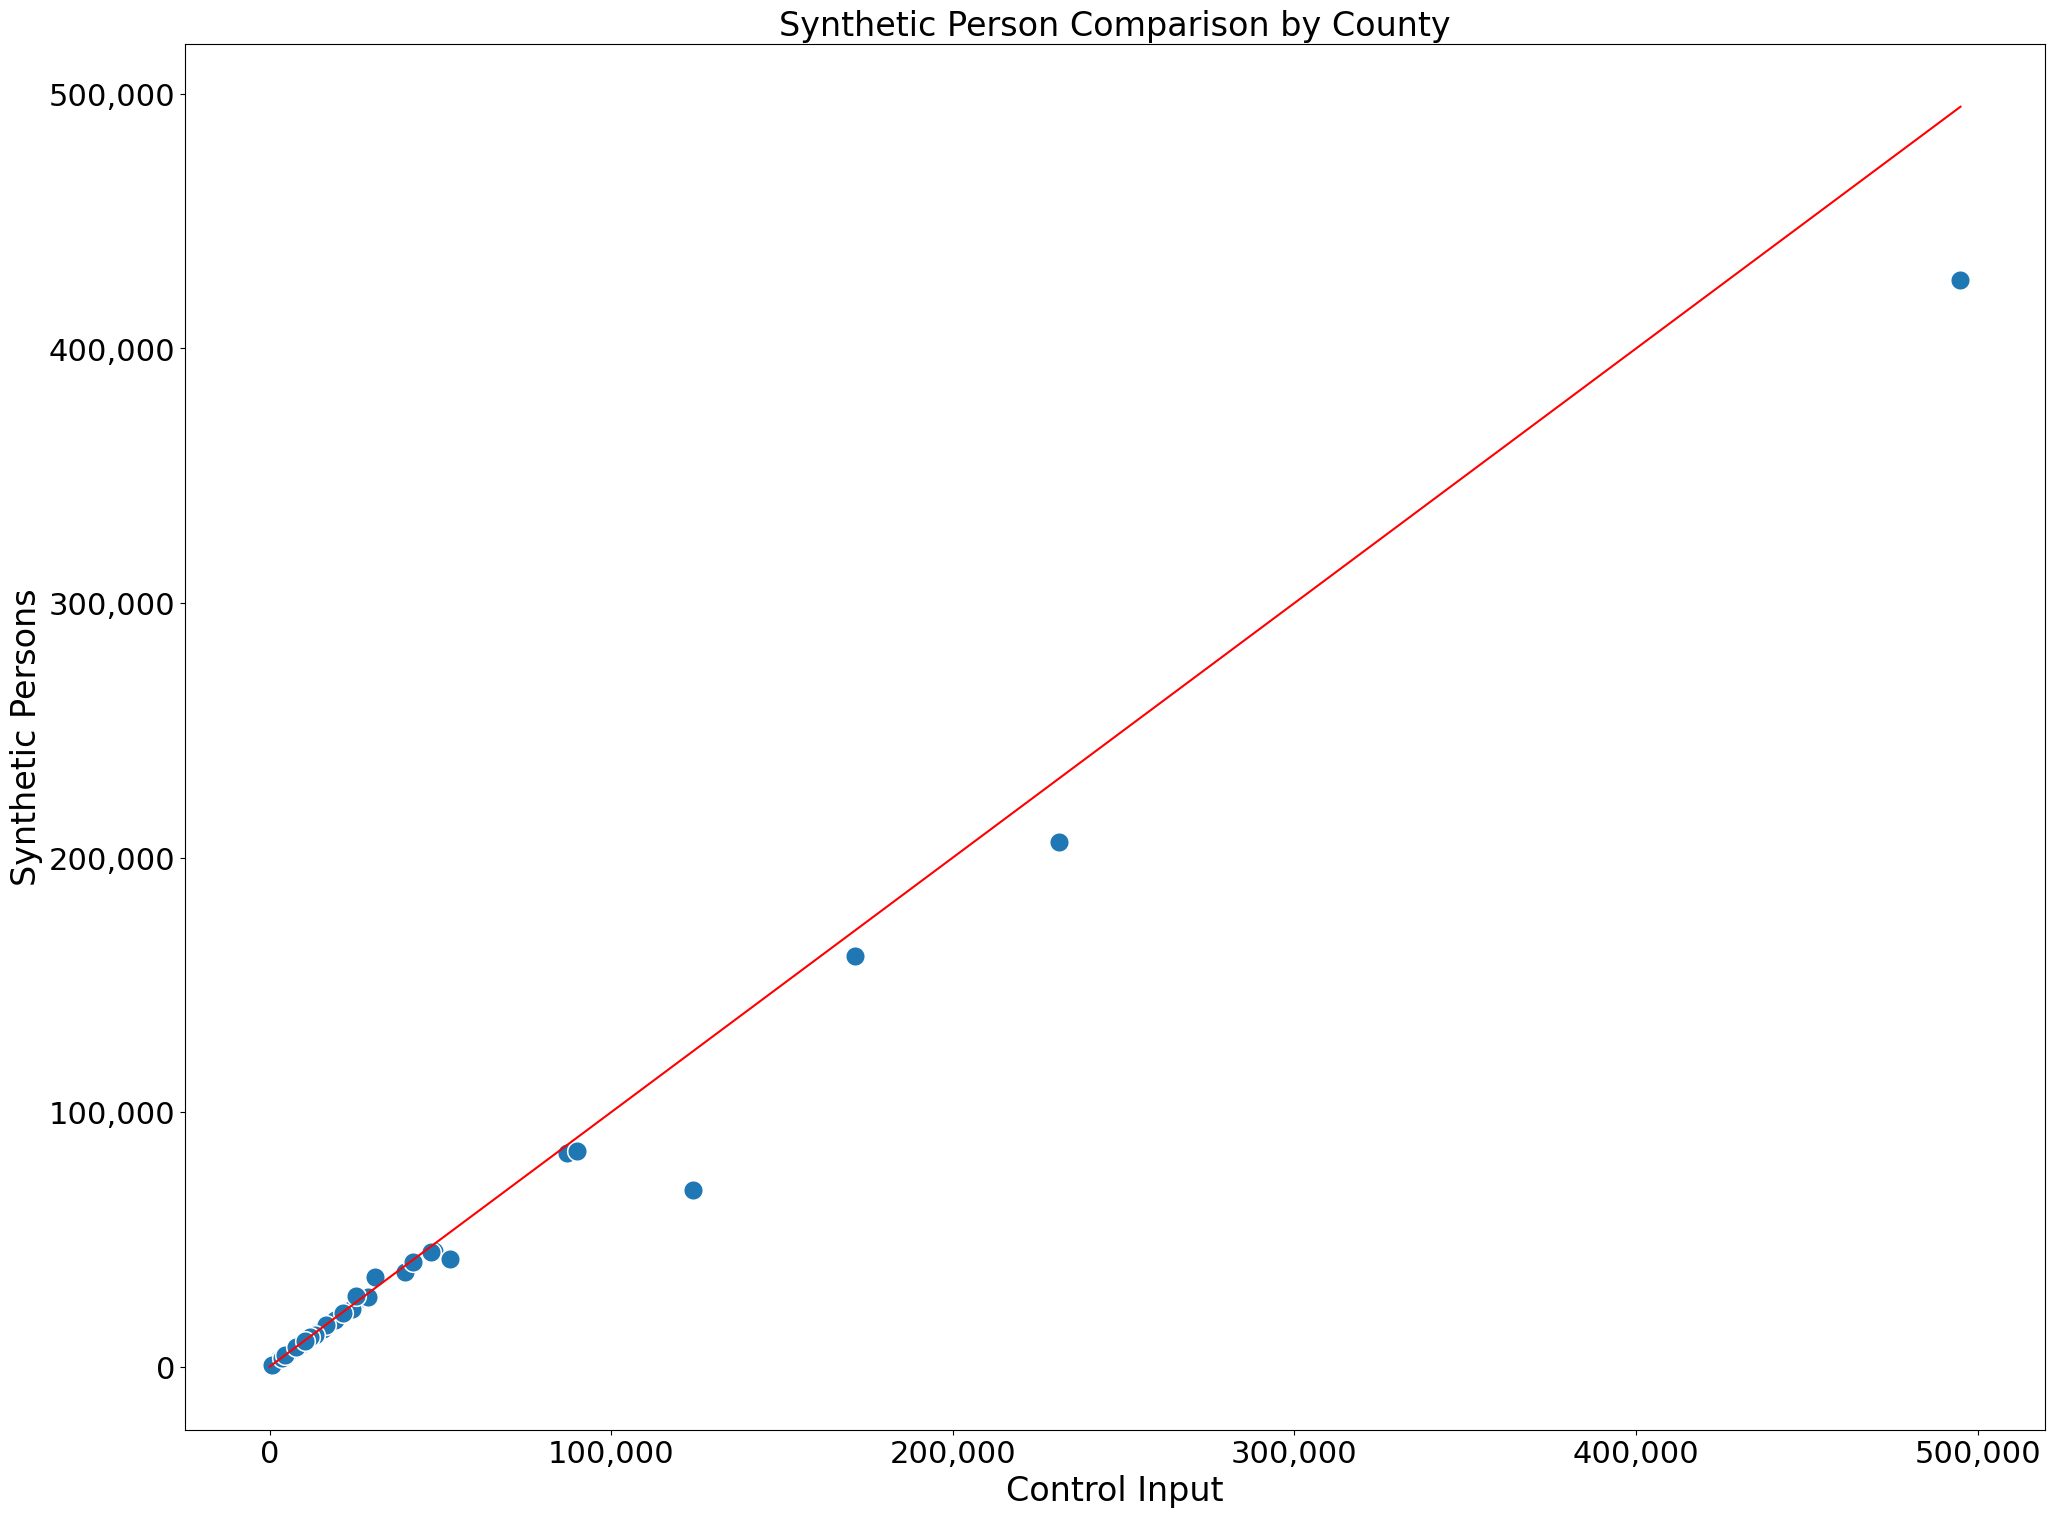

In [24]:
x_pred = np.linspace(0, np.max(np.max(co_pop_compare[['control', 'synper']])), 100)

fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
# sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
# sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
# sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = co_pop_compare, x = 'control', y = 'synper', s = 200) #, c = plot_data['FTYPE'].map(ftype_colors))
# plt.text(60000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
# plt.text(60000, 7000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.title(f"Synthetic Person Comparison by County", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Synthetic Persons', fontsize=24)
plt.xlabel('Control Input', fontsize=24)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

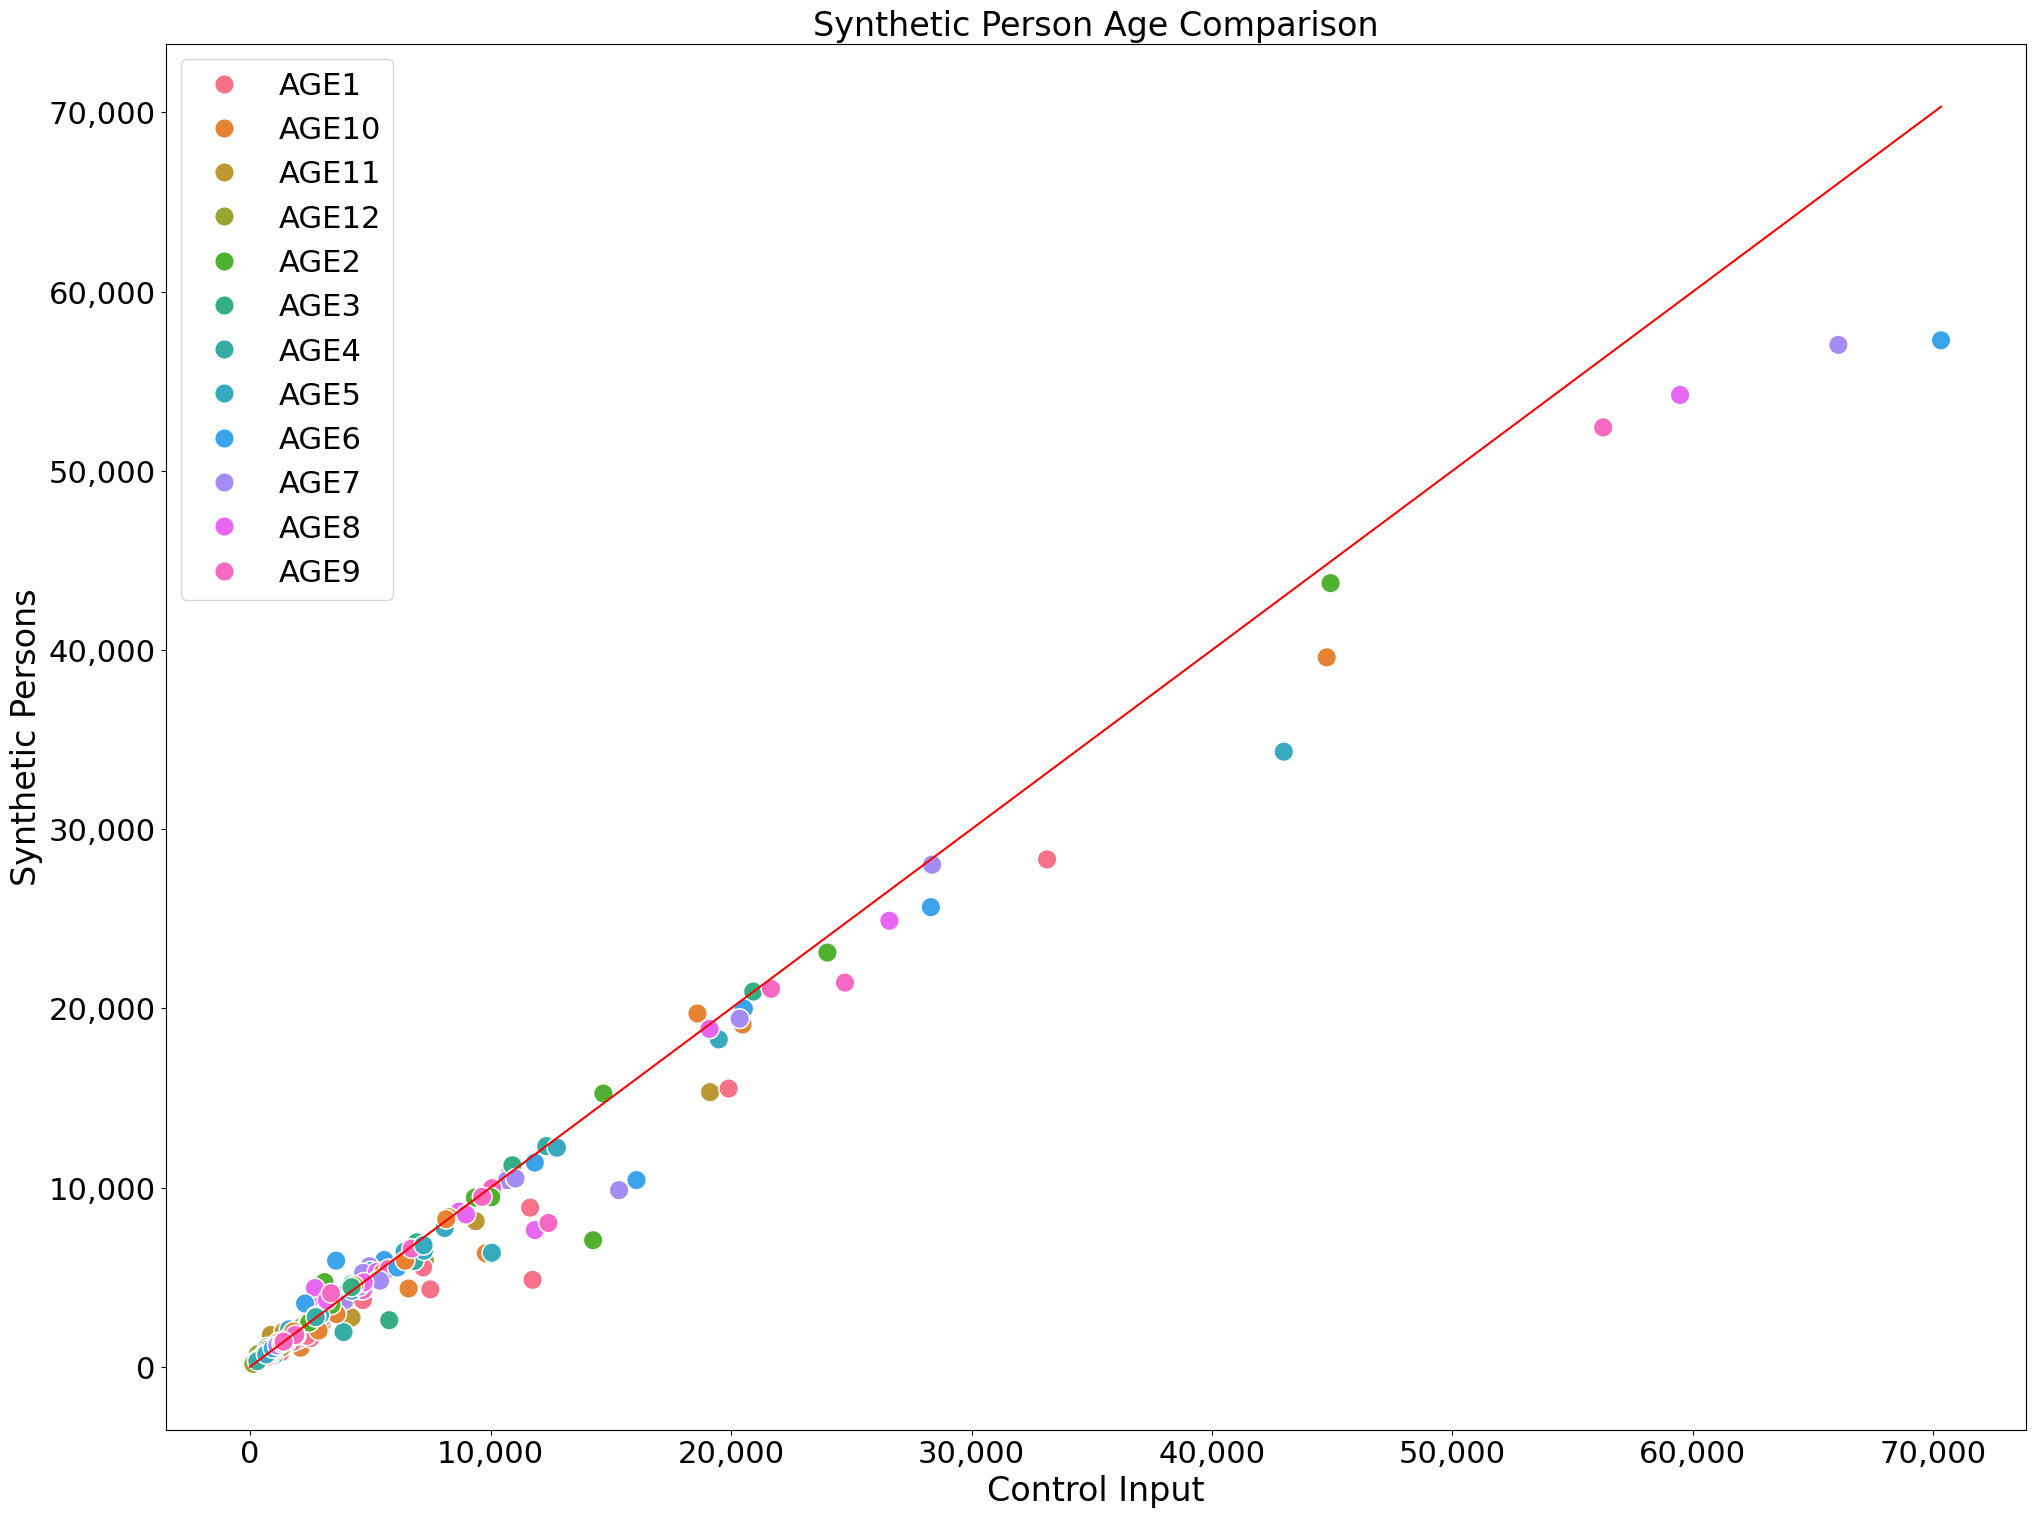

In [34]:
x_pred = np.linspace(0, np.max(np.max(age_compare[['control', 'synper']])), 100)

age_colors = {'AGE1': '#a6cee3', 'AGE2': '#1f78b4', 'AGE3': '#b2df8a', 'AGE4': '#33a02c', 'AGE5': '#fb9a99', 'AGE6': '#e31a1c',
    'AGE7': '#fdbf6f', 'AGE8': '#ff7f00', 'AGE9': '#cab2d6', 'AGE10': '#6a3d9a', 'AGE11': '#ffff99', 'AGE12': '#b15928'}

fig, ax = plt.subplots(figsize=(24, 18))
plot_idx = 111
plt.subplot(plot_idx)
sns.lineplot(x=x_pred, y=x_pred, ax=ax, color = 'red')
# sns.lineplot(x = x_pred, y = poly1d_fn(x_pred), ax = ax, color = 'black', linestyle='dashed')
# sns.lineplot(x = x_pred, y = x_pred + 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
# sns.lineplot(x = x_pred2, y = x_pred2 - 3.0 * plot_data.Count.std(), color = 'green', linestyle = 'dashed')
sns.scatterplot(data = age_compare, x = 'control', y = 'synper', s = 200, hue = age_compare['AGEGP']) #, c = plot_data['FTYPE'].map(ftype_colors))
# handles = [i for i in np.unique(age_compare['AGEGP'].map(age_colors))]

# plt.text(60000, 10000, f"$r^2 = {plot_data[['Model', 'Count']].corr()['Model']['Count']**2:.4f}$", fontsize=22)
# plt.text(60000, 7000, f"y = {m:.4f}x {'+' if b >= 0 else ''} {b:,.0f}", fontsize=22)
plt.title(f"Synthetic Person Age Comparison", fontsize=24)
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.ylabel('Synthetic Persons', fontsize=24)
plt.xlabel('Control Input', fontsize=24)
plt.legend(fontsize = 22)
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
ax.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.show()